In [63]:
from numba import njit
from hftbacktest import NONE, NEW, FILLED, CANCELED, EXPIRED, GTC, MARKET
import numpy as np

# Strategy Design


In [64]:
import numpy as np

from hftbacktest import (
    BacktestAsset,
    HashMapMarketDepthBacktest,
    ROIVectorMarketDepthBacktest,
    Recorder
)
from hftbacktest.stats import LinearAssetRecord

Save the backtest module into `lib/pmm.py`


In [65]:
import lib.pmm_pure as pmm_pure
import lib.pmm as pmm

In [66]:
# %%time

ethusdt_20250630 = np.load('data/output/ethusdt_20250630.npz')['data']
ethusdt_20250701 = np.load('data/output/ethusdt_20250701.npz')['data']

asset = (
    BacktestAsset()
    .data([
        ethusdt_20250630,
        ethusdt_20250701,
    ])
    .initial_snapshot('data/output/ethusdt_20250629_eod.npz')
    .linear_asset(1)
    .risk_adverse_queue_model()
    .no_partial_fill_exchange()
    .constant_latency(10_000_000, 10_000_000)
    # .tick_size(0.01)
    .tick_size(0.01)  # 最小 Price precision (0.01 USDT)
    # .lot_size(0.001)
    .lot_size(0.01)  # 最小 Trading amount (0.001 ETH)
    .trading_value_fee_model(-0.00003, 0.0007)  # Binance
    # .last_trades_capacity(1000)
)

roi_lb = 2000    # ROI下界100tick，订单簿深度计算的价格下限
roi_ub = 3500    # ROI上界200tick，订单簿深度计算的价格上限


hbt = HashMapMarketDepthBacktest([asset])
recorder = Recorder(1, 1_000_000_000)

order_qty_dollar = 20


_ = pmm_pure.pure_pmm(
    hbt,
    recorder.recorder,
    half_spread=6,
    skew=1,
    interval=600_000_000,
    order_qty_dollar=order_qty_dollar,
    max_position_dollar=25000,
    grid_num=10,
    grid_interval=hbt.depth(0).tick_size
)

_ = hbt.close()

recorder.to_npz('stats/pmm_ethusdt.npz')

In [67]:
data = np.load('stats/pmm_ethusdt.npz')['0']
stats = (
    LinearAssetRecord(data)
    .resample('1s')
    .stats(book_size=50)
    # .stats()
)
stats.summary()

start,end,SR,Sortino,Return,MaxDrawdown,DailyNumberOfTrades,DailyTurnover,ReturnOverMDD,ReturnOverTrade,MaxPositionValue
datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-06-30 00:00:00,2025-07-01 03:50:33,-437.008346,-874.650693,-3.946165,3.946323,134338.798599,66703.438503,-0.99996,-0.000051,644.9833


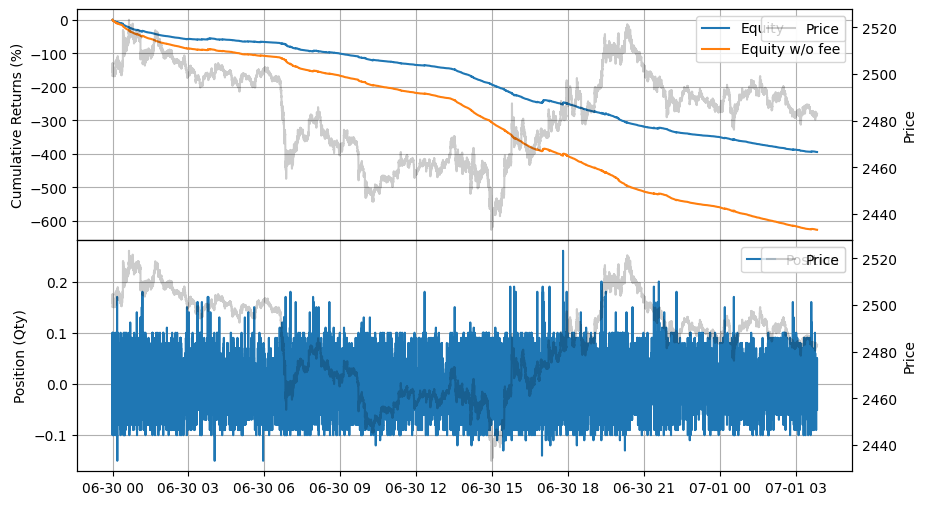

In [68]:
stats.plot()